In [1]:
import polars as pl
import sys
from pathlib import Path
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")
from IPython.display import HTML, display

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from project.helpers import init_client
from project.cl_model import (
    prepare_data,
    fit_ols_sm,
    plot_heatmap,
)

from IPython.display import HTML

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


In [2]:
start = "2015-01-01"
end = "2025-11-01"
client = init_client()

data = prepare_data(start=start, end=end, client=client, target_delta=0.25, constant_targets=(21, 42)).set_index("date") # constant_targets
term_structure_cols = ["slope_m1_m2", "slope_const_21_42"]
skew_cols= ["skew_25d", "iv_25c", "iv_25p"]

In [3]:
data.columns

Index(['slope_m1_m2', 'slope_const_21_42', 'const_price_21d',
       'const_price_42d', 'underlying', 'expiration', 'iv_25c', 'iv_25p',
       'skew_25d', 'slope_25d', 'atm_iv', 'slope_sign'],
      dtype='object')

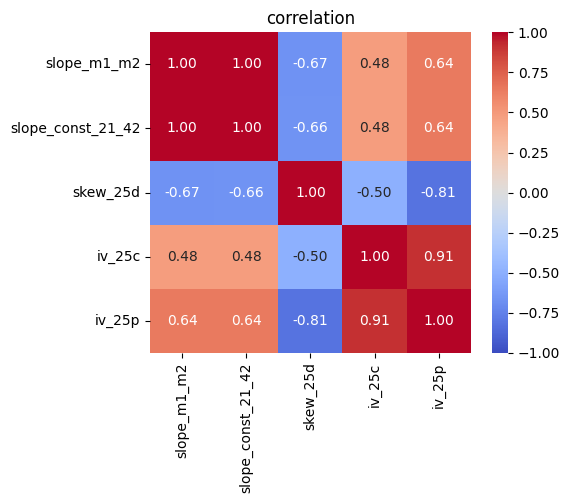

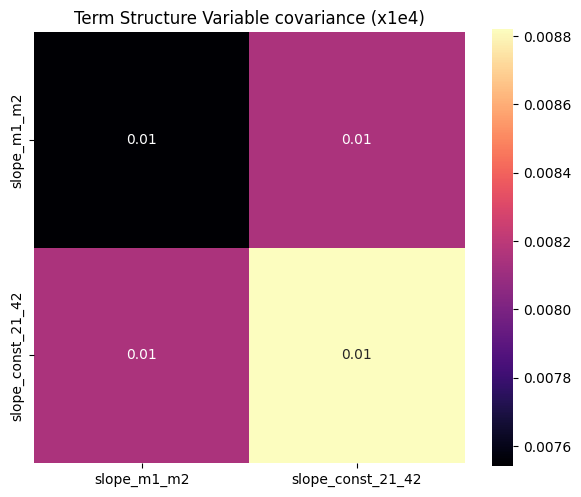

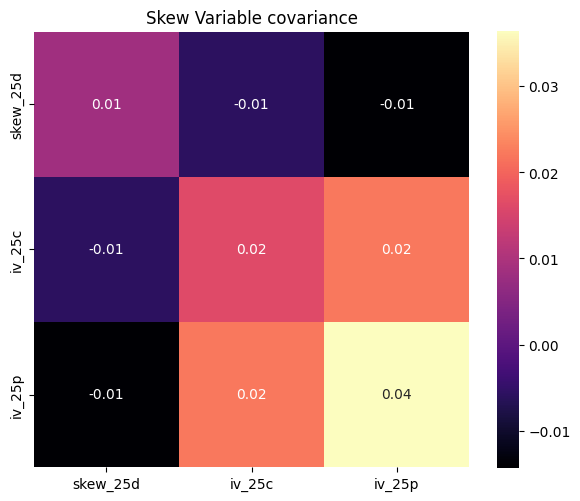

In [4]:
# correlation heatmap
plot_heatmap(data, cols=term_structure_cols + skew_cols, title="correlation", vmin=-1, vmax=1)

# covariance heatmap
cov = data[term_structure_cols].cov() * 1e4
plot_heatmap(data, matrix=cov, title=f"Term Structure Variable covariance (x1e4)", vmin=None, vmax=None, cmap="magma")

cov = data[skew_cols].cov()
plot_heatmap(data, matrix=cov, title=f"Skew Variable covariance", vmin=None, vmax=None, cmap="magma")

## Regression

In [5]:
reg_simple = fit_ols_sm(data, "skew_25d", ["slope_const_21_42"])
html = reg_simple.summary().as_html()
display(HTML(f"<div style='background:white;color:black;padding:10px;font-family:\"Times New Roman\", Times, serif'>{html}</div>"))

In [ ]:
reg_extended = fit_ols_sm(data, "skew_25d", ["slope_const_21_42", "atm_iv", "slope_sign"])
html = reg_extended.summary().as_html()
display(HTML(f"<div style='background:white;color:black;padding:10px;font-family:\"Times New Roman\", Times, serif'>{html}</div>"))

## Prediction

In [ ]:
# sort and build t+1 target
data = data.sort_values(["underlying", "date"])
data["skew_25d_l1"] = data.groupby("underlying")["skew_25d"].shift(1)
data["slope_const_21_42_l1"] = data.groupby("underlying")["slope_const_21_42"].shift(1)
data["atm_iv_l1"] = data.groupby("underlying")["atm_iv"].shift(1)
data["slope_sign_l1"] = data.groupby("underlying")["slope_sign"].shift(1)

data["d_skew_25d"] = data["skew_25d"] - data["skew_25d_l1"]

X_cols = ["skew_25d_l1", "slope_const_21_42_l1", "atm_iv_l1", "slope_sign_l1"]
df_reg = data.dropna(subset=["d_skew_25d"] + X_cols)

pred_model = fit_ols_sm(df_reg, "d_skew_25d", X_cols)

html = pred_model.summary().as_html()
display(HTML("<div style='background:white;color:black;padding:10px;font-family:\"Times New Roman\", Times, serif'>"f"{html}</div>"))

Train size: 322
Test size: 47


Model,MSE,MAE
OOS regression,0.002830,0.037726
Naive (Δskew = 0),0.003602,0.043735


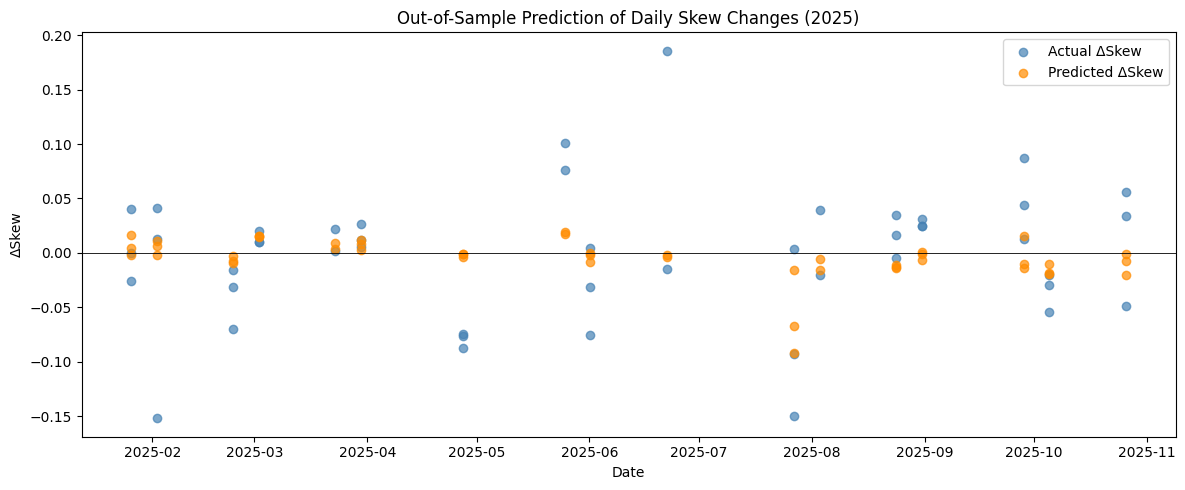

In [ ]:
# Ensure 'date' is a column (not index)
if df_reg.index.name == "date" and "date" not in df_reg.columns:
    df_reg = df_reg.reset_index()
if hasattr(df_reg["date"].dtype, "tz") and df_reg["date"].dtype.tz is not None:
    df_reg["date"] = df_reg["date"].dt.tz_convert(None)
cutoff = pd.Timestamp("2025-01-01")

train = df_reg[df_reg["date"] < cutoff]
test  = df_reg[df_reg["date"] >= cutoff]
print("Train size:", len(train))
print("Test size:", len(test))

# Fit model on training data 
def fit_ols_sm(df: pd.DataFrame, y_col: str, x_cols: list[str]):
    df_clean = df.dropna(subset=[y_col] + x_cols)
    X = sm.add_constant(df_clean[x_cols])
    y = df_clean[y_col]
    return sm.OLS(y, X).fit()

oos_model = fit_ols_sm(train, "d_skew_25d", X_cols)
test = test.copy()
test["pred"] = oos_model.predict(sm.add_constant(test[X_cols]))
mse = mean_squared_error(test["d_skew_25d"], test["pred"])
mae = mean_absolute_error(test["d_skew_25d"], test["pred"])

# naive benchmark: predict zero change (d_skew = 0)
mse_naive = mean_squared_error(test["d_skew_25d"], 0 * test["d_skew_25d"])
mae_naive = mean_absolute_error(test["d_skew_25d"], 0 * test["d_skew_25d"])

oos_results = pd.DataFrame(
    {
        "Model": ["OOS regression", "Naive (Δskew = 0)"],
        "MSE":  [mse, mse_naive],
        "MAE":  [mae, mae_naive],
    }
).round(6)
html_oos = oos_results.to_html(index=False)
display(HTML(
    "<div style='background:white;color:black;padding:10px;font-family:\"Times New Roman\", Times, serif'>"
    "<h4 style='text-align:center;margin-top:0;'>Table 4: Out-of-Sample Forecast Performance (2025)</h4>"
    f"{html_oos}"
    "</div>"
))

plt.figure(figsize=(12, 5))
plt.scatter(test["date"], test["d_skew_25d"], label="Actual ΔSkew", color="steelblue", alpha=0.7)
plt.scatter(test["date"], test["pred"], label="Predicted ΔSkew", color="darkorange", alpha=0.7)
plt.axhline(0, color="black", linewidth=0.6)
plt.title("Out-of-Sample Prediction of Daily Skew Changes (2025)")
plt.xlabel("Date")
plt.ylabel("ΔSkew")
plt.legend()
plt.tight_layout()
plt.show()